# Week 20: Sensor-to-field learning with missing observations

Does set attention help when sensor cardinality changes, after accounting for representation and fitting budget?

**Prerequisites:** Week 19 sensing contract; Week 4/5 POD-DeepONet; Week 15 operator vocabulary.

Allow 120 minutes plus the written analysis. Student edition: worked examples run immediately; set RUN_EXERCISES=True after completing the four functions. Incomplete tasks are reported, never counted as passes.

In [1]:
from pathlib import Path
import sys, tempfile, json
ROOT=next((p for p in [Path.cwd(),*Path.cwd().parents] if (p/'flowmllab/transformer_course.py').exists()),None)
if ROOT is None:
    raise RuntimeError('Extract the supplied course bundle and start Jupyter in its root; see docs/TRANSFORMER_COURSE.md for Colab upload setup.')
sys.path.insert(0,str(ROOT))
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from IPython.display import display
from flowmllab import transformer_course as lab
lab.seed_all(17)
cases,input_manifest=lab.load_data(ROOT)
EVIDENCE=ROOT/'results/transformer_course_v3'
# Any optional experiment must write into this disposable workspace.
workspace=tempfile.TemporaryDirectory(prefix='flowmllab-student-')
RUN_OUTPUT=Path(workspace.name)
task_status={}
print('Loaded checksummed simulated wake fields. No retained files will be rewritten.')


Loaded checksummed simulated wake fields. No retained files will be rewritten.


In [2]:
RUN_EXERCISES=False

## Train a small set model during the laboratory

This 120-step classroom run is deliberately labeled a short optimization exercise. The release evidence uses the full protocol. Change the budget and examine the validation curve before comparing methods.

{'selected_step': 90, 'executed_steps': 120, 'ceiling': 120, 'at_budget_boundary': False, 'validation_mse': 0.02791085932765523, 'seconds': 82.87723069998901, 'parameters': 5192}


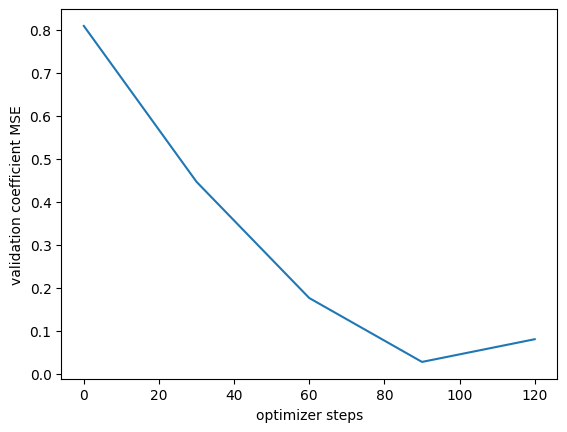

In [3]:
from dataclasses import replace
p=replace(lab.Protocol(),max_steps=120,seeds=(17,))
training=np.concatenate([cases[r]['v'][::4] for r in p.train_re]);rep=lab.Representation.fit(training,8)
ids=lab.qr_sensors(rep,16);mean,scale=float(training.mean()),float(training.std())
x=lab.sensor_tokens(training,ids,cases[90],mean,scale);y=rep.encode(training)
vx=lab.sensor_tokens(cases[100]['v'][::4],ids,cases[90],mean,scale);vy=rep.encode(cases[100]['v'][::4])
model=lab.SensorSet();record=lab.fit(model,x,y,lambda m:np.mean((lab.infer(m,vx)-vy)**2),p)
print({k:v for k,v in record.items() if k!='history'})
plt.plot([r['step'] for r in record['history']],[r['validation_mse'] for r in record['history']]);plt.xlabel('optimizer steps');plt.ylabel('validation coefficient MSE');plt.show()

## Audit the retained all-sensor and dropout comparisons

The set model was trained with cardinality augmentation. Fixed-input networks and ridge use declared training-mean imputation under dropout. Gappy POD solves directly on the available coordinates. This is a system comparison, not a perfectly capacity-matched architecture ablation.

In [4]:
record=json.loads((EVIDENCE/'sensors.json').read_text())
table=[{'method':r['method'],'seed':r['seed'],'condition':r['condition'],'field':r['metrics']['field_relative_l2'],'floor':r['metrics']['representation_floor'],'subspace':r['metrics']['in_subspace_relative_l2'],'boundary':r.get('training',{}).get('at_budget_boundary')} for r in record['rows']]
display(pd.DataFrame(table))
retained=np.load(EVIDENCE/'predictions.npz',allow_pickle=False)
row=record['rows'][0];pred=lab.prediction(retained,'sensors__'+row['key'])
recomputed=np.linalg.norm(pred-cases[105]['v'].reshape(281,-1))/np.linalg.norm(cases[105]['v'])
assert abs(recomputed-row['metrics']['field_relative_l2'])<1e-7
print('Rescored retained prediction:',recomputed)

,method,seed,condition,field,floor,subspace,boundary
0,Sensor-set,17.0,all,0.135542,0.040492,0.129353,False
1,Sensor-set,17.0,drop-half,0.271587,0.040492,0.268551,False
2,POD-DeepONet,17.0,all,0.040890,0.040492,0.005689,False
3,POD-DeepONet,17.0,drop-half,0.481596,0.040492,0.479891,False
4,Sensor-set,29.0,all,0.144320,0.040492,0.138523,False
5,Sensor-set,29.0,drop-half,0.249896,0.040492,0.246594,False
6,POD-DeepONet,29.0,all,0.041159,0.040492,0.007381,False
7,POD-DeepONet,29.0,drop-half,0.483329,0.040492,0.481630,False
8,Sensor-set,43.0,all,0.116094,0.040492,0.108804,False
9,Sensor-set,43.0,drop-half,0.226201,0.040492,0.222547,False


Rescored retained prediction: 0.1355423993507345


## Task 1: Cardinality-preserving token dropout

Remove every other sensor from values and coordinates together; never reinterpret a missing value as an observed zero.

In [5]:
def drop_half(tokens):
    raise NotImplementedError

In [6]:
if RUN_EXERCISES:
    d=drop_half(x)
    assert d.shape==(len(x),8,3)
    np.testing.assert_array_equal(d[:,:,1:],x[:,::2,1:])
    task_status[1]=True
else:
    task_status[1]=False
print("Task 1:","PASS" if task_status[1] else "NOT SUBMITTED")

Task 1: NOT SUBMITTED


## Task 2: Capacity accounting

Count trainable parameters; compare the attention model with the 16-64-8 branch network.

In [7]:
def parameter_count(model):
    raise NotImplementedError

In [8]:
if RUN_EXERCISES:
    branch=torch.nn.Sequential(torch.nn.Linear(16,64),torch.nn.Tanh(),torch.nn.Linear(64,8))
    assert parameter_count(branch)==1608
    assert parameter_count(model)>0
    task_status[2]=True
else:
    task_status[2]=False
print("Task 2:","PASS" if task_status[2] else "NOT SUBMITTED")

Task 2: NOT SUBMITTED


## Task 3: Training budget diagnosis

Flag a record whose selected checkpoint reaches its ceiling. This diagnoses an unresolved budget limit, not proof of convergence or its absence.

In [9]:
def boundary_flag(record):
    raise NotImplementedError

In [10]:
if RUN_EXERCISES:
    assert boundary_flag({"selected_step":120,"ceiling":120})
    assert not boundary_flag({"selected_step":90,"ceiling":120})
    task_status[3]=True
else:
    task_status[3]=False
print("Task 3:","PASS" if task_status[3] else "NOT SUBMITTED")

Task 3: NOT SUBMITTED


## Task 4: Compute-aware ranking

Select the best validation record under a wall-time budget; evaluation metrics must not enter selection.

In [11]:
def select_under_budget(records,seconds):
    raise NotImplementedError

In [12]:
if RUN_EXERCISES:
    rs=[{"seconds":1.,"validation_mse":.2},{"seconds":3.,"validation_mse":.1}]
    assert select_under_budget(rs,2.) is rs[0]
    task_status[4]=True
else:
    task_status[4]=False
print("Task 4:","PASS" if task_status[4] else "NOT SUBMITTED")

Task 4: NOT SUBMITTED


## Interpretation and submission

Submit the four completed functions, the requested plots/tables, and a 300-word claim ledger. Distinguish observations, fitted quantities, independent evaluation and unsupported extrapolation. Retain failed seeds. Use the lecture source for the rubric and assumptions.

In [13]:
print("Coding tasks passed:",sum(task_status.values()),"/",len(task_status))
workspace.cleanup()

Coding tasks passed: 0 / 4
